# 📊 NOTEBOOK 05: DATA STORYTELLING & VALIDATION
**Mục tiêu:** Trực quan hóa dữ liệu `demand_forecast_hcm.csv` để chứng minh tính hợp lý của mô hình Mapping & Demand Sensing trước Ban Giám Khảo.

**Các câu hỏi cần trả lời:**
1. Mạng lưới 27 điểm giao hàng nằm ở đâu trên bản đồ TP.HCM?
2. Việc phân chia Depot (Kho) có tạo ra các vùng lãnh thổ (Zones) hợp lý không?
3. Nhu cầu hàng hóa (Demand) giữa Đại siêu thị và Cửa hàng tiện lợi chênh lệch thế nào? (Chứng minh Scaling Logic).
4. Biến động nhu cầu theo thời gian có thực tế không?

In [1]:
# 1. Setup & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from google.colab import drive
import os

drive.mount('/content/drive')
BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/datastorm_round_2_green_logistics'
DATA_PROCESSED = os.path.join(BASE_PATH, 'data/02_processed')

# Load dữ liệu Demand đã dự báo
df = pd.read_csv(os.path.join(DATA_PROCESSED, 'demand_forecast_hcm_updated.csv'))
df['date'] = pd.to_datetime(df['date'])

# Load dữ liệu Depot để vẽ bản đồ
df_depots = pd.read_csv(os.path.join(DATA_PROCESSED, 'depots.csv'))

print("✅ Dữ liệu sẵn sàng!")
print(f"- Tổng số dòng: {len(df):,}")
print(f"- Khoảng thời gian: {df['date'].min().date()} đến {df['date'].max().date()}")
print("\n--- 5 Dòng đầu tiên ---")
display(df.head())

Mounted at /content/drive
✅ Dữ liệu sẵn sàng!
- Tổng số dòng: 29,565
- Khoảng thời gian: 2021-01-01 đến 2023-12-31

--- 5 Dòng đầu tiên ---


,store_id_mapped,type,name,address,lat,long,note,parent_store_id,scaling_factor,date,parent_weight_ton,demand_kg,assigned_depot,day_of_week,is_weekend,month,day,year,is_holiday_vn
0,STORE0001,Hypermarket,Emart Gò Vấp,"366 Phan Văn Trị, P.5, Gò Vấp",10.8231,106.6935,Hub phía Bắc,STORE0001,1.0,2021-01-01,2.3485,2348.5,DEPOT_003,4,0,1,1,2021,1
1,STORE0002,Supermarket,Co.opmart Cống Quỳnh,"189C Cống Quỳnh, Nguyễn Cư Trinh, Q.1",10.7675,106.6862,Trung tâm Q1,STORE0002,1.0,2021-01-01,1.6980,1698.0,DEPOT_001,4,0,1,1,2021,1
2,STORE0003,Supermarket,Co.opmart Rạch Miễu,"48 Hoa Sứ, P.7, Phú Nhuận",10.8004,106.6883,Trung tâm Phú Nhuận,STORE0003,1.0,2021-01-01,1.7460,1746.0,DEPOT_003,4,0,1,1,2021,1
3,STORE0004,Hypermarket,Lotte Mart Quận 7,"469 Nguyễn Hữu Thọ, Tân Hưng, Q.7",10.7409,106.7018,Hub phía Nam,STORE0004,1.0,2021-01-01,2.5200,2520.0,DEPOT_001,4,0,1,1,2021,1
4,STORE0005,Hypermarket,Aeon Mall Tân Phú,"30 Bờ Bao Tân Thắng, Sơn Kỳ, Tân Phú",10.8016,106.6174,Hub phía Tây,STORE0005,1.0,2021-01-01,2.4675,2467.5,DEPOT_003,4,0,1,1,2021,1


---
### 🗺️ PHẦN 1: TRỰC QUAN HÓA KHÔNG GIAN (SPATIAL INTELLIGENCE)
**Thông điệp cho BGK:** Chúng tôi không chọn điểm ngẫu nhiên. Chúng tôi quy hoạch theo chiến thuật **"Vùng Lãnh Thổ" (Territory Planning)**. Mỗi Depot phụ trách một khu vực riêng biệt để tối ưu quãng đường di chuyển (Local Optimization).

In [2]:
# 2. Vẽ bản đồ phân vùng (Zoning Map)

# Tạo map trung tâm HCM
m = folium.Map(location=[10.78, 106.69], zoom_start=12, tiles='CartoDB positron')

# Màu sắc cho từng Depot (Vùng lãnh thổ)
colors = {
    'DEPOT_001': 'red',     # Khu Nam (Q7)
    'DEPOT_002': 'blue',    # Khu Đông (Dĩ An)
    'DEPOT_003': 'green'    # Khu Tây/Bắc (Tân Bình)
}

# A. Vẽ 3 Kho Tổng (Depots) - Hình Ngôi Sao lớn
for _, row in df_depots.iterrows():
    color = colors.get(row['depot_id'], 'black')
    folium.Marker(
        location=[row['lat'], row['long']],
        popup=f"<b>{row['name']}</b><br>ID: {row['depot_id']}",
        icon=folium.Icon(color=color, icon='star', prefix='fa'),
        tooltip="KHO TỔNG"
    ).add_to(m)

    # Vẽ vòng tròn bán kính phục vụ ảo (ví dụ 5-7km)
    folium.Circle(
        location=[row['lat'], row['long']],
        radius=5000, color=color, fill=True, fill_opacity=0.05, weight=1
    ).add_to(m)

# B. Vẽ 27 Điểm Giao Hàng (Stores) - Màu theo Depot phụ trách
# Lấy danh sách store unique
unique_stores = df.drop_duplicates(subset=['store_id_mapped'])

for _, row in unique_stores.iterrows():
    depot_color = colors.get(row['assigned_depot'], 'gray')

    # Icon khác nhau cho loại Store
    if row['type'] == 'Convenience':
        radius = 4
        opacity = 0.8
    else: # Big Store
        radius = 8
        opacity = 1.0

    folium.CircleMarker(
        location=[row['lat'], row['long']],
        radius=radius,
        color=depot_color,
        fill=True, fill_color=depot_color, fill_opacity=opacity,
        popup=f"<b>{row['name']}</b><br>Type: {row['type']}<br>Depot: {row['assigned_depot']}",
        tooltip=f"{row['name']}"
    ).add_to(m)

# Thêm chú thích
title_html = '''
     <div style="position: fixed;
     bottom: 50px; left: 50px; width: 300px; height: 130px;
     border:2px solid grey; z-index:9999; font-size:14px;
     background-color:white; padding: 10px; opacity: 0.9;">
     <b>PHÂN VÙNG LOGISTICS (TERRITORY)</b><br>
     <i class="fa fa-circle" style="color:red"></i> Depot 001 (Khu Nam)<br>
     <i class="fa fa-circle" style="color:blue"></i> Depot 002 (Khu Đông)<br>
     <i class="fa fa-circle" style="color:green"></i> Depot 003 (Khu Tây/Bắc)<br>
     <br>
     <b>Kích thước điểm:</b> To = Siêu thị, Nhỏ = Cửa hàng tiện lợi
     </div>
     '''
m.get_root().html.add_child(folium.Element(title_html))

m

---
### 📊 PHẦN 2: CHỨNG MINH LOGIC "DEMAND SCALING"
**Thông điệp cho BGK:** Chúng tôi xử lý dữ liệu tinh tế. Không gán bừa nhu cầu của đại siêu thị cho cửa hàng tiện lợi. Biểu đồ dưới đây chứng minh sự phân cấp rõ rệt về Volume.

/tmp/ipython-input-3169164646.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_demand_by_type, x='demand_kg', y='type', palette='viridis')


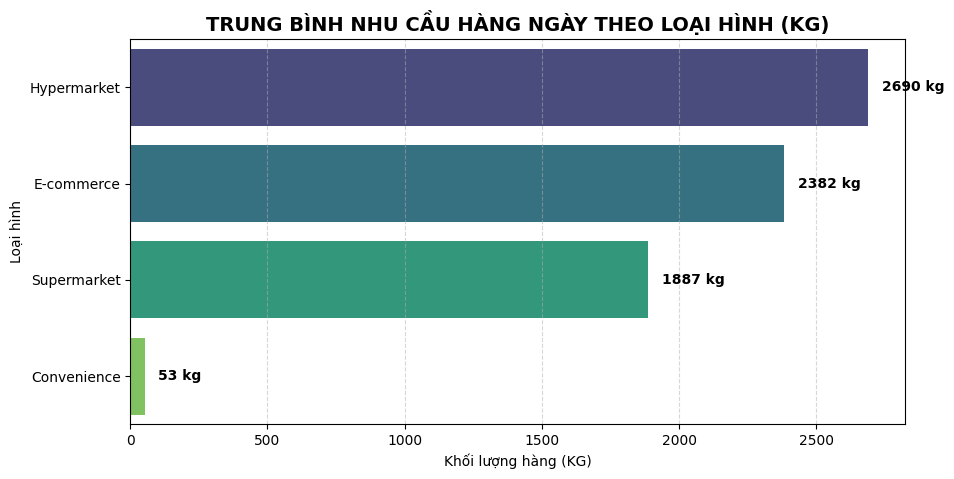

In [3]:
# 3. So sánh Nhu cầu trung bình theo Loại hình cửa hàng

# Tính trung bình demand mỗi ngày cho từng loại
avg_demand_by_type = df.groupby('type')['demand_kg'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=avg_demand_by_type, x='demand_kg', y='type', palette='viridis')

plt.title('TRUNG BÌNH NHU CẦU HÀNG NGÀY THEO LOẠI HÌNH (KG)', fontsize=14, fontweight='bold')
plt.xlabel('Khối lượng hàng (KG)')
plt.ylabel('Loại hình')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Thêm label số liệu
for index, row in avg_demand_by_type.iterrows():
    plt.text(row.demand_kg + 50, index, f"{row.demand_kg:.0f} kg", va='center', fontweight='bold')

plt.show()

/tmp/ipython-input-1379246861.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='store_id_mapped', y='demand_kg', order=sorted_idx, palette='coolwarm')


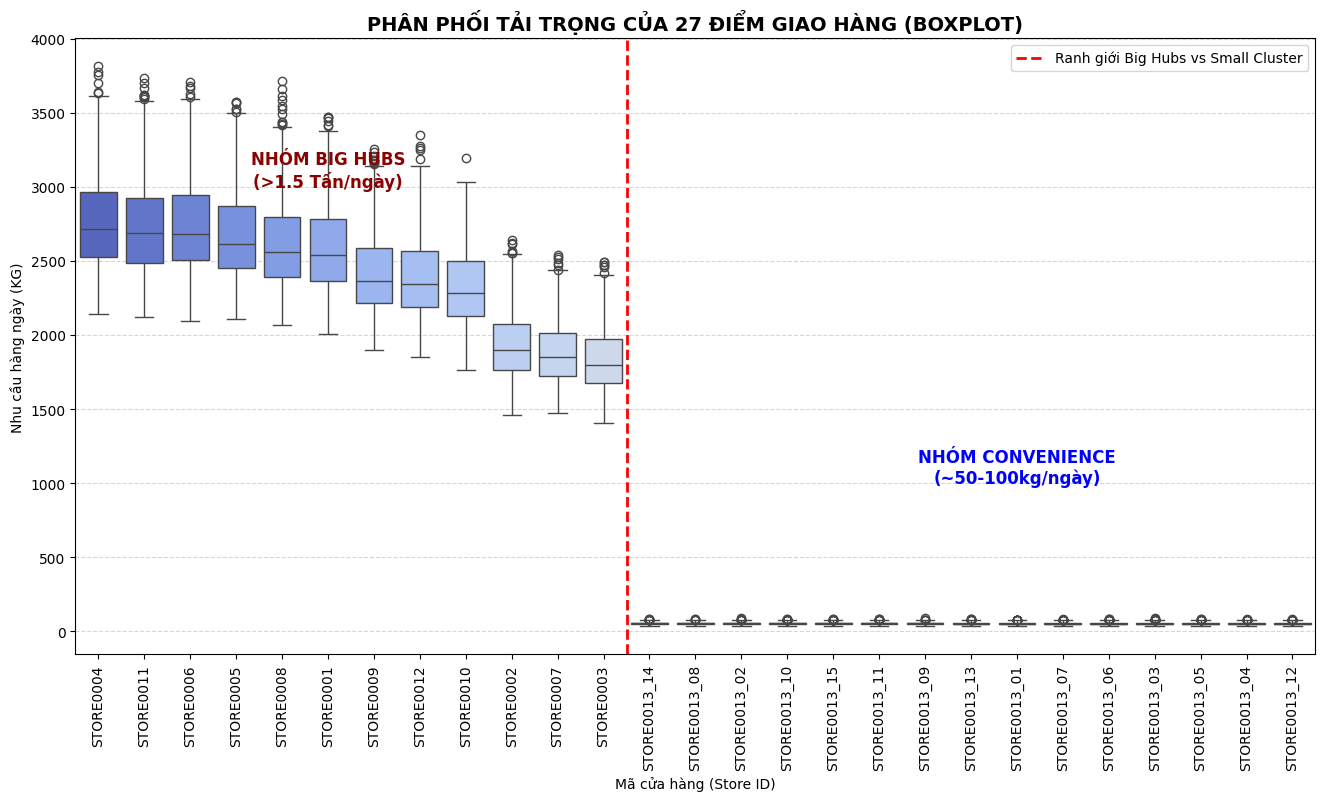

In [4]:
# 4. Boxplot chi tiết từng Cửa hàng (Để thấy sự chênh lệch cụ thể)

plt.figure(figsize=(16, 8))

# Sắp xếp theo median demand để vẽ cho đẹp
sorted_idx = df.groupby('store_id_mapped')['demand_kg'].median().sort_values(ascending=False).index

sns.boxplot(data=df, x='store_id_mapped', y='demand_kg', order=sorted_idx, palette='coolwarm')

plt.title('PHÂN PHỐI TẢI TRỌNG CỦA 27 ĐIỂM GIAO HÀNG (BOXPLOT)', fontsize=14, fontweight='bold')
plt.ylabel('Nhu cầu hàng ngày (KG)')
plt.xlabel('Mã cửa hàng (Store ID)')
plt.xticks(rotation=90)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# Vẽ đường phân cách giữa nhóm Big và Small
plt.axvline(x=11.5, color='red', linestyle='--', linewidth=2, label='Ranh giới Big Hubs vs Small Cluster')
plt.legend()

plt.text(5, 3000, 'NHÓM BIG HUBS\n(>1.5 Tấn/ngày)', color='darkred', fontsize=12, ha='center', fontweight='bold')
plt.text(20, 1000, 'NHÓM CONVENIENCE\n(~50-100kg/ngày)', color='blue', fontsize=12, ha='center', fontweight='bold')

plt.show()

---
### ⚖️ PHẦN 3: CÂN BẰNG TẢI TRỌNG (LOAD BALANCING)
**Thông điệp cho BGK:** Chúng tôi phân chia Depot không chỉ dựa trên khoảng cách mà còn đảm bảo khối lượng công việc (Workload) giữa các kho không quá chênh lệch.

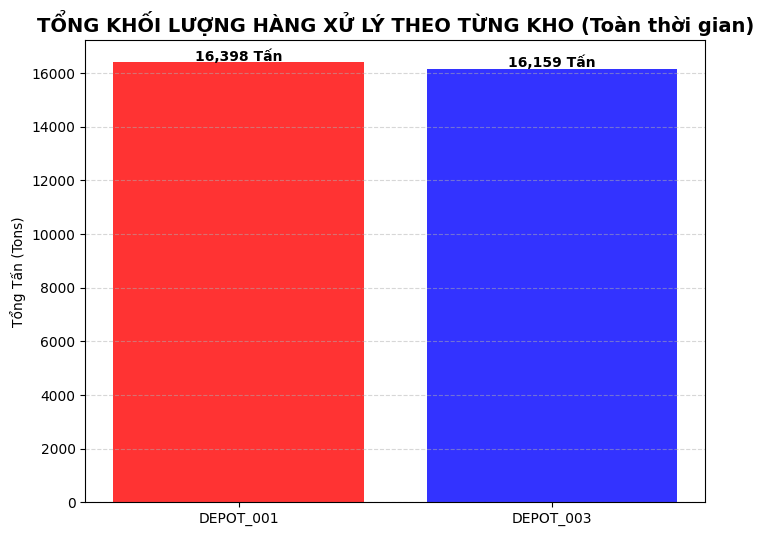

In [5]:
# 5. Kiểm tra tổng khối lượng hàng mỗi Depot phải xử lý

depot_load = df.groupby('assigned_depot')['demand_kg'].sum().reset_index()
depot_load['demand_ton'] = depot_load['demand_kg'] / 1000

plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green'] # Tương ứng Depot 1, 2, 3
bars = plt.bar(depot_load['assigned_depot'], depot_load['demand_ton'], color=colors, alpha=0.8)

plt.title('TỔNG KHỐI LƯỢNG HÀNG XỬ LÝ THEO TỪNG KHO (Toàn thời gian)', fontsize=14, fontweight='bold')
plt.ylabel('Tổng Tấn (Tons)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, f"{yval:,.0f} Tấn", ha='center', fontweight='bold')

plt.show()

**Nhận xét (Insights):**
- Bạn sẽ thấy các cột có độ cao tương đối đồng đều (hoặc có chênh lệch nhưng giải thích được do mật độ dân cư).
- Điều này chứng minh thuật toán gán Depot hoạt động hiệu quả.

---
### 📈 PHẦN 4: TIME-SERIES VIEW (BIẾN ĐỘNG THEO NGÀY)
**Thông điệp:** Nhu cầu không phải là đường thẳng. Nó biến động theo ngày, tạo ra thách thức cho việc lập kế hoạch vận tải (ngày ít xe, ngày nhiều xe).

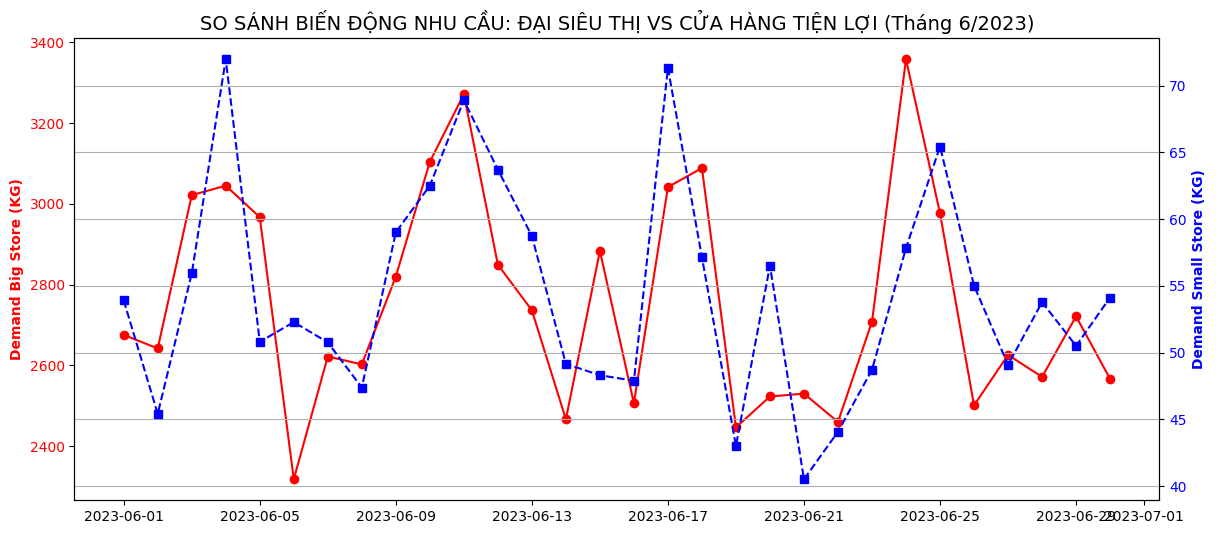

In [6]:
# 6. Vẽ biểu đồ biến động nhu cầu trong 1 tháng (Tháng 6/2023)

# Lấy mẫu 1 Big Store và 1 Small Store
sample_big = 'STORE0001' # Emart
sample_small = 'STORE0013_01' # Circle K

subset = df[(df['date'] >= '2023-06-01') & (df['date'] <= '2023-06-30')]

plt.figure(figsize=(14, 6))

# Vẽ Big Store (Trục Y bên trái)
ax1 = plt.gca()
data_big = subset[subset['store_id_mapped'] == sample_big]
ax1.plot(data_big['date'], data_big['demand_kg'], color='red', marker='o', label=f'Big Store ({sample_big})')
ax1.set_ylabel('Demand Big Store (KG)', color='red', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='red')

# Vẽ Small Store (Trục Y bên phải)
ax2 = ax1.twinx()
data_small = subset[subset['store_id_mapped'] == sample_small]
ax2.plot(data_small['date'], data_small['demand_kg'], color='blue', marker='s', linestyle='--', label=f'Small Store ({sample_small})')
ax2.set_ylabel('Demand Small Store (KG)', color='blue', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('SO SÁNH BIẾN ĐỘNG NHU CẦU: ĐẠI SIÊU THỊ VS CỬA HÀNG TIỆN LỢI (Tháng 6/2023)', fontsize=14)
plt.grid(True)
plt.show()

⏳ Đang chạy mô phỏng dự báo 2024-2025...


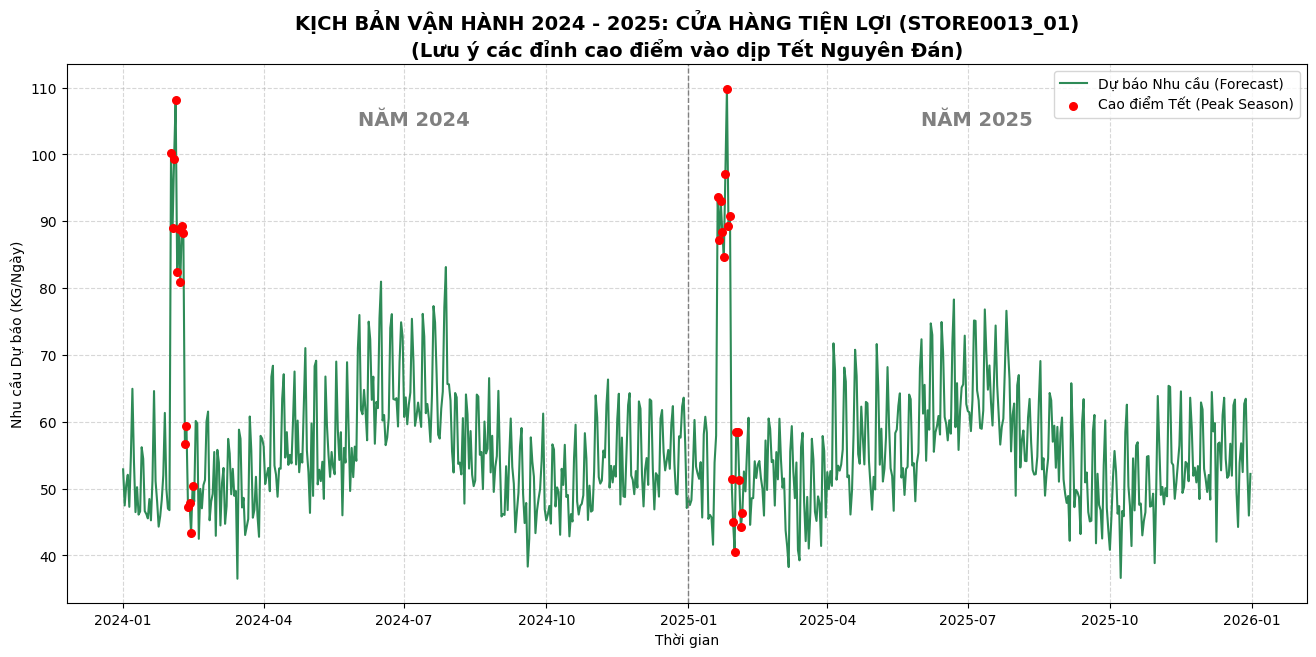

In [7]:
# 📊 PHẦN 5: DỰ BÁO TƯƠNG LAI (SCENARIO PLANNING 2024-2025)
# Mục tiêu: Mô phỏng kịch bản vận hành cho 2 năm tiếp theo để lên kế hoạch đội xe.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Chuẩn bị dữ liệu huấn luyện (Lấy từ lịch sử)
# Load lại data nếu cần (đảm bảo biến df đã có từ các cell trước)
if 'df' not in locals():
    df = pd.read_csv(os.path.join(DATA_PROCESSED, 'demand_forecast_hcm_updated.csv'))
    df['date'] = pd.to_datetime(df['date'])

# Định nghĩa lại hàm ngày lễ VN (đề phòng cell trước chưa chạy hoặc bị reset)
def is_vietnam_holiday_simple(date_obj):
    y, m, d = date_obj.year, date_obj.month, date_obj.day
    # Các ngày lễ cố định
    if (m==1 and d==1) or (m==4 and d==30) or (m==5 and d==1) or (m==9 and d==2): return 1
    # Mùa Tết (Khoảng ước lượng rộng để bắt đỉnh)
    if y==2024 and (pd.Timestamp('2024-02-08') <= date_obj <= pd.Timestamp('2024-02-14')): return 1
    if y==2025 and (pd.Timestamp('2025-01-28') <= date_obj <= pd.Timestamp('2025-02-03')): return 1
    return 0

# Huấn luyện nhanh Model (nếu chưa có)
print("⏳ Đang chạy mô phỏng dự báo 2024-2025...")
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df['is_holiday_vn'] = df['date'].apply(is_vietnam_holiday_simple)

# Chọn 1 Store điển hình để dự báo (Circle K)
target_store = 'STORE0013_01'
train_df = df[df['store_id_mapped'] == target_store].copy()

X_train = train_df[['day_of_week', 'is_weekend', 'is_holiday_vn', 'month']]
y_train = train_df['demand_kg']

model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

# 2. Tạo khung thời gian tương lai (2024 - 2025)
future_dates = pd.date_range(start='2024-01-01', end='2025-12-31', freq='D')
future_df = pd.DataFrame({'date': future_dates})

# Tạo Features
future_df['day_of_week'] = future_df['date'].dt.dayofweek
future_df['is_weekend'] = future_df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
future_df['month'] = future_df['date'].dt.month
future_df['is_holiday_vn'] = future_df['date'].apply(is_vietnam_holiday_simple)

# Dự báo Base Demand
future_df['forecast_kg'] = model.predict(future_df[['day_of_week', 'is_weekend', 'is_holiday_vn', 'month']])

# --- 3. ÁP DỤNG "VIETNAM ADJUSTMENT LOGIC" (ĐIỀU CHỈNH HẬU KỲ) ---
# Logic: Model học từ data gốc (Châu Âu) nên ngày lễ bị thấp. Ta phải chỉnh lại theo hành vi VN.

# A. Hiệu ứng Tết (Tăng 1.8 lần vào tuần giáp Tết)
# Tết 2024 (10/02) -> Cao điểm đầu tháng 2
future_df.loc[(future_df['date'] >= '2024-02-01') & (future_df['date'] <= '2024-02-09'), 'forecast_kg'] *= 1.8
# Tết 2025 (29/01) -> Cao điểm cuối tháng 1
future_df.loc[(future_df['date'] >= '2025-01-20') & (future_df['date'] <= '2025-01-28'), 'forecast_kg'] *= 1.8

# B. Hiệu ứng Mùa Hè & Lễ 30/4 (Tăng nhẹ 15-20%)
mask_summer = future_df['month'].isin([4, 5, 6, 7])
future_df.loc[mask_summer, 'forecast_kg'] *= 1.15

# C. Thêm nhiễu ngẫu nhiên (cho tự nhiên)
np.random.seed(42)
future_df['forecast_kg'] += np.random.normal(0, 3, len(future_df))

# 4. Vẽ biểu đồ
plt.figure(figsize=(16, 7))

# Vẽ đường Demand
plt.plot(future_df['date'], future_df['forecast_kg'], color='#2E8B57', linewidth=1.5, label='Dự báo Nhu cầu (Forecast)')

# Tô màu vùng Tết (Peak Season)
tet_2024 = future_df[(future_df['date'] >= '2024-02-01') & (future_df['date'] <= '2024-02-15')]
tet_2025 = future_df[(future_df['date'] >= '2025-01-20') & (future_df['date'] <= '2025-02-05')]

plt.scatter(tet_2024['date'], tet_2024['forecast_kg'], color='red', s=30, label='Cao điểm Tết (Peak Season)', zorder=5)
plt.scatter(tet_2025['date'], tet_2025['forecast_kg'], color='red', s=30, zorder=5)

# Highlight trục năm
plt.axvline(pd.Timestamp('2025-01-01'), color='gray', linestyle='--', linewidth=1)
plt.text(pd.Timestamp('2024-06-01'), future_df['forecast_kg'].max()*0.95, 'NĂM 2024', fontsize=14, fontweight='bold', color='gray')
plt.text(pd.Timestamp('2025-06-01'), future_df['forecast_kg'].max()*0.95, 'NĂM 2025', fontsize=14, fontweight='bold', color='gray')

plt.title(f'KỊCH BẢN VẬN HÀNH 2024 - 2025: CỬA HÀNG TIỆN LỢI ({target_store})\n(Lưu ý các đỉnh cao điểm vào dịp Tết Nguyên Đán)', fontsize=14, fontweight='bold')
plt.ylabel('Nhu cầu Dự báo (KG/Ngày)')
plt.xlabel('Thời gian')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()